In [3]:
import numpy as np
import pandas as pd
from tqdm import tqdm


In [5]:
def load_subset(filepath, max_ratings=500000):
    data = []
    movie_id = None

    with open(filepath, "r", encoding="utf-8") as f:

        for line in tqdm(f):

            if line.endswith(":\n"):
                movie_id = int(line[:-2])

            else:
                user_id, rating, date = line.strip().split(",")

                data.append([
                    int(user_id),
                    movie_id,
                    int(rating),
                    date
                ])

                if len(data) >= max_ratings:
                    break

    return pd.DataFrame(
        data,
        columns=["user_id","movie_id","rating","date"]
    )

In [13]:
df = load_subset(
    "../data/combined_data_1.txt",
    max_ratings=500000
)

500147it [00:00, 876950.29it/s] 


In [17]:
print("Rows:", len(df))
print("Users:", df.user_id.nunique())
print("Movies:", df.movie_id.nunique())

Rows: 500000
Users: 215008
Movies: 148


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   500000 non-null  int64 
 1   movie_id  500000 non-null  int64 
 2   rating    500000 non-null  int64 
 3   date      500000 non-null  object
dtypes: int64(3), object(1)
memory usage: 15.3+ MB


rating
1     25328
2     52351
3    147206
4    174284
5    100831
Name: count, dtype: int64


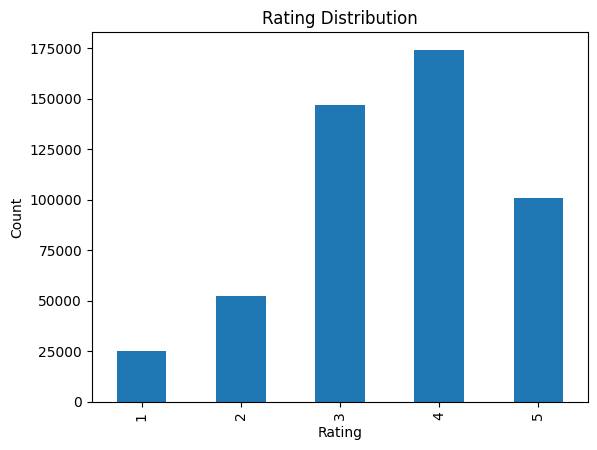

In [19]:
import matplotlib.pyplot as plt

rating_counts = (
    df.rating
      .value_counts()
      .sort_index()
)

print(rating_counts)

rating_counts.plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The rating distribution is positively skewed, with ratings 3, 4, and 5 accounting for the majority of user feedback. Rating 4 is the most frequently assigned score, indicating that users generally provide favorable evaluations of watched content. Low ratings (1 and 2) are comparatively rare, suggesting the presence of positive feedback bias. From a business perspective, this indicates strong user satisfaction and effective content discovery. From a technical perspective, the imbalance in rating frequencies may bias recommendation models toward predicting higher ratings, making accurate ranking among highly rated items a more challenging task.

In [20]:
user_activity = (
    df.groupby("user_id")
      .size()
)

user_activity.describe()

count    215008.000000
mean          2.325495
std           2.301144
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         143.000000
dtype: float64

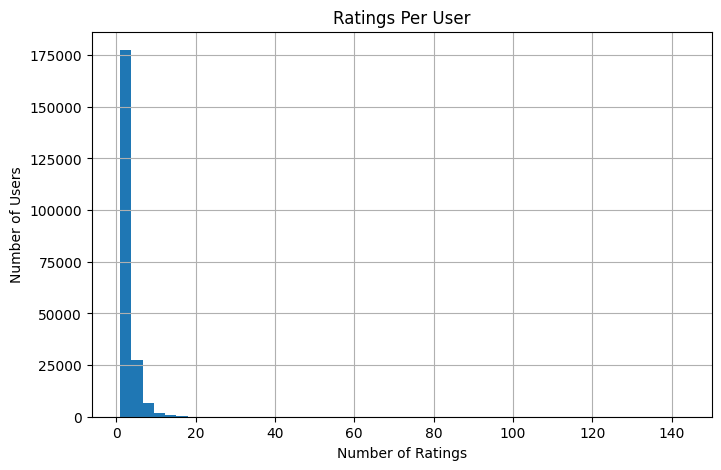

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
user_activity.hist(bins=50)

plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

In [38]:
user_activity.sort_values(ascending=False).head(10)

user_id
305344     143
387418     143
2439493    140
1664010    127
2118461    117
1461435     82
1639792     78
1932594     78
2056022     71
1114324     71
dtype: int64

User activity follows a highly skewed long-tail distribution. While the average user in the sampled dataset provided approximately 2.3 ratings, the median user provided only 2 ratings. A small subset of highly active users contributed significantly more ratings, with the most active user rating 143 movies. This long-tail behavior indicates that most users provide limited feedback, creating challenges for personalization and user similarity estimation. From a business perspective, understanding and engaging highly active users is valuable because they contribute a large portion of interaction data. The platform may benefit from encouraging greater user participation to improve personalization. From a technical perspective, sparse user profiles introduce cold-start challenges and reduce the effectiveness of user-based collaborative filtering methods, motivating the use of item-based and latent-factor recommendation approaches.

In [28]:
movie_popularity = (
    df.groupby("movie_id")
      .size()
)

movie_popularity.describe()

count       148.000000
mean       3378.378378
std       11322.141906
min          78.000000
25%         182.750000
50%         471.500000
75%        1893.500000
max      118413.000000
dtype: float64

In [40]:
movie_popularity.sort_values(ascending=False).head(10)

movie_id
30     118413
28      39752
143     38362
111     30127
118     19240
108     19018
83      18724
58      17405
8       14910
77      13598
dtype: int64

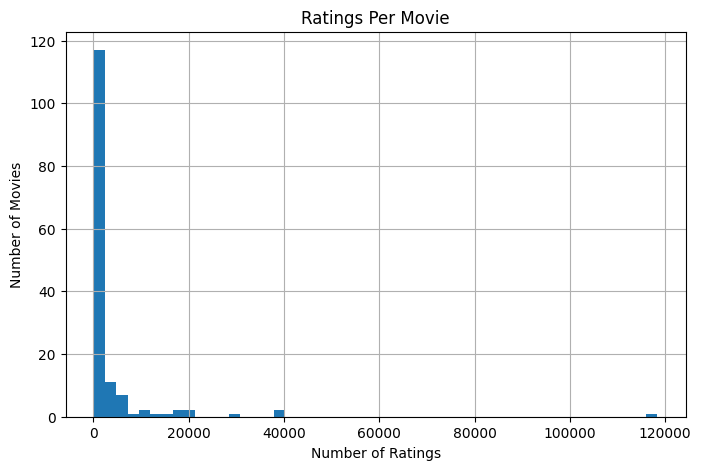

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

movie_popularity.hist(bins=50)

plt.title("Ratings Per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.show()

Movie popularity exhibits a highly skewed long-tail distribution. While the median movie received approximately 472 ratings, the most popular movie accumulated over 118,000 ratings. The large gap between the mean and median number of ratings indicates that user interactions are concentrated around a small set of highly popular titles. From a business perspective, this highlights the importance of content discovery mechanisms that expose users to less popular but relevant content. From a technical perspective, popularity bias may cause recommendation models to over-recommend blockbuster movies, reducing recommendation diversity and personalization quality.

In [46]:
num_users = df.user_id.nunique()
num_movies = df.movie_id.nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(df)

sparsity = 1 - (actual_ratings / possible_ratings)

print("Users:", num_users)
print("Movies:", num_movies)
print("Actual Ratings:", actual_ratings)
print("Possible Ratings:", possible_ratings)
print("Sparsity:", sparsity)

Users: 215008
Movies: 148
Actual Ratings: 500000
Possible Ratings: 31821184
Sparsity: 0.9842871968560315


The sampled dataset exhibits extreme sparsity, with only 500,000 observed ratings out of more than 31.8 million possible user–movie interactions, resulting in a sparsity level of approximately 98.43%. This indicates that users have interacted with only a very small fraction of available content. From a business perspective, such sparsity highlights the importance of recommendation systems for content discovery and user engagement. From a technical perspective, the large proportion of missing interactions makes traditional predictive approaches unsuitable and motivates the use of collaborative filtering and matrix factorization techniques capable of learning from sparse data.

## Interesting Observations & Insights

**Insight 1**

Users generally provide positive ratings (3–5 dominate).

**Insight 2**

User activity follows a long-tail distribution; a small fraction of users contribute disproportionately large amounts of data.

**Insight 3**

Movie popularity is highly concentrated around a few blockbuster titles.

**Insight 4**

The dataset is extremely sparse (98.43%), making recommendation generation a non-trivial task.

**Insight 5**

The combination of popularity skew and sparsity creates a risk of popularity bias, where recommendation systems may repeatedly recommend already popular movies while ignoring niche content.